In [1]:
# Работа с данными
import pandas as pd
import numpy as np
import requests

# Визуализации
import matplotlib.pyplot as plt
import plotly.express as px

# Тесты на стационарность
from statsmodels.tsa.stattools import adfuller, kpss

# Тест на автокорреляцию
from statsmodels.stats.diagnostic import acorr_ljungbox

# Анализ автокорреляции
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Модели ARMA
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.arima.model import ARIMA


# import warnings
# warnings.filterwarnings("ignore")

# Для воспроизводимости
np.random.seed(42)


In [2]:
super_stationary = [np.random.normal(0, np.sqrt(1 / (1 - 0.5**2)))]

# Генерируем 400 значений и отбрасываем первые 100
for i in range(1, 400):
    super_stationary.append(
        0.5 * super_stationary[i-1] + np.random.normal(loc=0, scale=1)
    )

super_stationary = super_stationary[100:]

In [5]:
ss_df = pd.DataFrame(super_stationary)
ss_df.columns = ['y']

In [7]:
ss_df.head()

,y
0,-1.535233
1,-1.188262
2,-0.936845
3,-1.270700
4,-0.796636


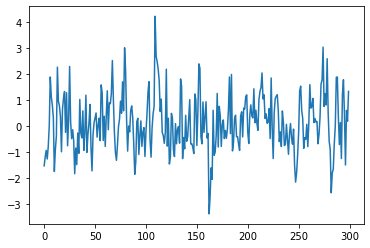

In [8]:
plt.plot(ss_df)

In [9]:
window_size = 10

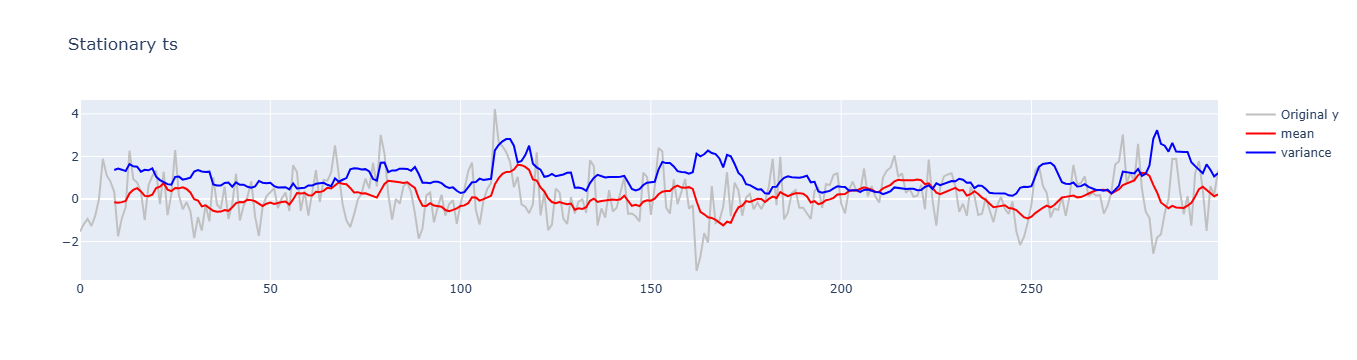

In [11]:
fig = px.line(title="Stationary ts")
fig.add_scatter(x=ss_df.index, y=ss_df['y'], mode='lines', name='Original y', line=dict(color='silver'))
fig.add_scatter(x=ss_df.index, y=ss_df['y'].rolling(window_size).mean(), mode='lines', name='mean', line=dict(color='red'))
fig.add_scatter(x=ss_df.index, y=ss_df['y'].rolling(window_size).var(), mode='lines', name='variance', line=dict(color='blue'))
fig.show()

In [14]:
adfuller(ss_df['y'], maxlag=10)[1]
# p-value < 0.05 => стационарный

2.286919816605671e-19

In [18]:
kpss(ss_df['y'])[1]
# p-value > 0.05 => стационарный

C:\Users\n.osipov\Anaconda3_new\lib\site-packages\statsmodels\tsa\stattools.py:1910: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  warnings.warn(


0.1

In [19]:
np.random.seed(42)
n = 100
ts = np.zeros(n)
for t in range(1, n):
    ts[t] = 0.8 * ts[t-1] + np.random.normal(0, 1) # текущее значение y[t] зависит от предыдущего y[t-1]

# Преобразуем в pandas Series для удобства
ts = pd.Series(ts)

In [20]:
ts

0     0.000000
1     0.496714
2     0.259107
3     0.854974
4     2.207009
        ...   
95   -0.466994
96   -1.837110
97   -1.173568
98   -0.677799
99   -0.537126
Length: 100, dtype: float64

In [21]:
acf_values = acf(ts, nlags=20)

C:\Users\n.osipov\Anaconda3_new\lib\site-packages\statsmodels\tsa\stattools.py:667: FutureWarning: fft=True will become the default after the release of the 0.12 release of statsmodels. To suppress this warning, explicitly set fft=False.
  warnings.warn(


In [22]:
print("ACF Values:")
print(acf_values)

ACF Values:
[ 1.          0.78404647  0.61578116  0.49756117  0.41251249  0.37107035
  0.2554868   0.16406134  0.07689854  0.05023708  0.02642356  0.04687584
  0.00188086 -0.02346431  0.00342331 -0.04552513 -0.03249788 -0.04310438
 -0.02479158 -0.0261305  -0.05677752]


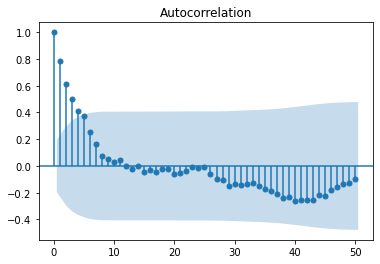

In [27]:
plot_acf(np.array(ts), lags = 50)
plt.show()

In [28]:
# Вычисляем значения PACF
pacf_values = pacf(ts, nlags=20)  # параметр nlags задаёт число лагов
print("PACF Values:")
print(pacf_values)

PACF Values:
[ 1.          0.79196613  0.00305205  0.03868411  0.03062518  0.08656093
 -0.20758234 -0.0197331  -0.08438734  0.0937683  -0.0504748   0.17878812
 -0.20252279  0.08983654  0.04261093 -0.18651241  0.07253536  0.0067831
  0.06827795 -0.09505722 -0.0259647 ]


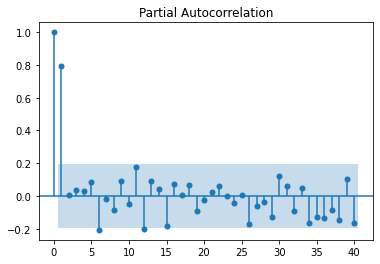

In [30]:
plot_pacf(np.array(ts), lags = 40)
plt.show()

In [31]:
acorr_ljungbox(ts, return_df=True)

C:\Users\n.osipov\Anaconda3_new\lib\site-packages\statsmodels\stats\diagnostic.py:531: FutureWarning: The default value of lags is changing.  After 0.12, this value will become min(10, nobs//5). Directly setlags to silence this warning.
  warnings.warn("The default value of lags is changing.  After 0.12, "


,lb_stat,lb_pvalue
1,63.335701,1.743161e-15
2,102.802045,4.751377e-23
3,128.834876,9.641650e-28
4,146.915073,9.326225e-31
5,161.698975,4.299577e-33
6,168.781844,8.153445e-34
7,171.733935,1.081729e-33
8,172.389550,4.069843e-33
9,172.672434,1.711770e-32
10,172.751563,7.467481e-32
